# 03 — Comprehensive Evaluation + LLM-as-a-Judge

The QLoRA training run achieved **macro F1 = 0.7312** vs CatBoost baseline 0.5707.
This notebook goes deeper: *where* does the model work, *where* does it fail, and what does GPT-4o-mini think?

**Sections:**
1. Load data + recreate test split
2. Run inference on 200-row stratified sample (GPU needed; or load saved CSV)
3. Confusion matrix + error breakdown
4. Confidence calibration
5. Segment analysis (per category, body type, review length)
6. LLM-as-a-Judge (OpenAI GPT-4o-mini) — < $0.10 for 100 samples
7. Robustness / edge case tests
8. Final scorecard

**Sections 3–8 run on CPU** — no GPU needed once predictions are saved.

In [5]:
# Run this cell first — installs all dependencies
# On RunPod this takes ~2 min; skip any lines already installed
!pip install -q unsloth trl peft bitsandbytes accelerate transformers
!pip install -q scikit-learn pandas numpy matplotlib openai pydantic tqdm pyarrow

In [1]:
import json, re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, classification_report
)
from pydantic import BaseModel
from typing import Literal

PRED_FILE   = 'results/predictions_sample.csv'   # saved after inference
ADAPTER_DIR = 'clothfit-adapter'
LABEL_MAP   = {'small': 0, 'fit': 1, 'large': 2}
LABEL_NAMES = ['small', 'fit', 'large']

os.makedirs('results', exist_ok=True)
print('Setup complete')

Setup complete


## Section 1 — Load data + recreate test split

We reconstruct the same test split used in training: sort by `review_date`, take the last 20%.
This is a time-based split — it prevents data leakage (future reviews can't inform past predictions).

In [2]:
def parse_height(h):
    """Convert '5\'6"' → 66 inches. Returns 0 on failure."""
    if not h or pd.isna(h):
        return 0
    h = str(h)
    m = re.search(r"(\d+)'\s*(\d+)", h)
    if m:
        return int(m.group(1)) * 12 + int(m.group(2))
    m = re.search(r'(\d+)', h)
    return int(m.group(1)) if m else 0

def parse_weight(w):
    """Convert '130lbs' → 130. Returns 0 on failure."""
    if not w or pd.isna(w):
        return 0
    m = re.search(r'(\d+)', str(w))
    return int(m.group(1)) if m else 0

raw = []
with open('data/renttherunway_final_data.json') as f:
    for line in f:
        raw.append(json.loads(line))

df = pd.DataFrame(raw)
df = df[df['fit'].isin(['small', 'fit', 'large'])].copy()
df['height_in']  = df['height'].apply(parse_height)
df['weight_lbs'] = df['weight'].apply(parse_weight)
df['review_text'] = df['review_text'].fillna('')
df['body_type']   = df['body type'].fillna('unknown')
df['age']         = pd.to_numeric(df['age'], errors='coerce').fillna(0).astype(int)
df['bust']        = df['bust size'].fillna('unknown')
df['category']    = df['category'].fillna('unknown')
df['size']        = df['size'].fillna('unknown')
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

# Time-based split: last 20% = test
df = df.sort_values('review_date').reset_index(drop=True)
n = len(df)
test_df = df.iloc[int(n * 0.8):].copy()

print(f'Total rows: {n:,} | Test rows: {len(test_df):,}')
print(f'Test fit distribution:\n{test_df["fit"].value_counts()}')

Total rows: 192,544 | Test rows: 38,509
Test fit distribution:
fit
fit      28059
small     5579
large     4871
Name: count, dtype: int64


## Section 2 — Inference on 200-row stratified sample

We sample **200 rows** (stratified: ~67 per class) from the test set.
This is enough for all analysis sections and takes ~12 minutes on RunPod A100.

**If you already ran this:** set `LOAD_FROM_FILE = True` to skip inference and load the saved CSV.

**If running on your laptop (RTX 3050):** inference may be slow (6GB VRAM is tight for 3B model in 4-bit).
Consider running just this section on RunPod after uploading the notebook.

## Section 2a — Zero-shot baseline (no fine-tuning)

Before running inference with your adapter, we run the **same prompts through the base model** (no LoRA).
This isolates how much the fine-tuning actually contributed vs what the model already knew.

**Expected result:** base Qwen2.5-3B zero-shot ≈ 0.50–0.55 macro F1.
Your fine-tuned model: 0.7312. The delta is the value of your training run.

Set `RUN_ZEROSHOT = True` to enable (adds ~12 min on RunPod). Results saved to `results/zeroshot_sample.csv`.

In [3]:
RUN_ZEROSHOT=True

In [8]:
RUN_ZEROSHOT   = True                       # set True to run; ~12 min on A100
ZEROSHOT_FILE  = 'results/zeroshot_sample.csv'
PRED_FILE      = 'results/predictions_sample.csv'
BASE_MODEL     = 'unsloth/Qwen2.5-3B-Instruct-bnb-4bit'
SAMPLE_N       = 200
LABEL_NAMES    = ['small', 'fit', 'large']

if not RUN_ZEROSHOT:
    print('Skipped — set RUN_ZEROSHOT=True to run zero-shot baseline.')
elif os.path.exists(ZEROSHOT_FILE):
    zs_df = pd.read_csv(ZEROSHOT_FILE)
    print(f'Loaded {len(zs_df)} saved zero-shot predictions from {ZEROSHOT_FILE}')
else:
    from unsloth import FastLanguageModel
    from tqdm import tqdm as _tqdm
    import re, json as _json

    zs_model, zs_tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL, max_seq_length=768, load_in_4bit=True,
    )
    FastLanguageModel.for_inference(zs_model)
    print(f'Loaded base model (no adapter): {BASE_MODEL}')

    # Rebuild test split independently
    raw_zs = []
    with open('data/renttherunway_final_data.json') as f:
        for line in f:
            raw_zs.append(_json.loads(line))
    df_zs = pd.DataFrame(raw_zs)
    df_zs = df_zs[df_zs['fit'].isin(LABEL_NAMES)].copy()
    df_zs['height_in']   = df_zs['height'].apply(lambda h: next((int(m.group(1))*12+int(m.group(2)) for m in [re.search(r"(\d+)'\s*(\d+)", str(h))] if m), 0))
    df_zs['weight_lbs']  = df_zs['weight'].apply(lambda w: int(m.group(1)) if (m := re.search(r'(\d+)', str(w))) else 0)
    df_zs['review_text'] = df_zs['review_text'].fillna('')
    df_zs['body_type']   = df_zs['body type'].fillna('unknown')
    df_zs['age']         = pd.to_numeric(df_zs['age'], errors='coerce').fillna(0).astype(int)
    df_zs['bust']        = df_zs['bust size'].fillna('unknown')
    df_zs['category']    = df_zs['category'].fillna('unknown')
    df_zs['size']        = df_zs['size'].fillna('unknown')
    df_zs['review_date'] = pd.to_datetime(df_zs['review_date'], errors='coerce')
    df_zs = df_zs.sort_values('review_date').reset_index(drop=True)
    test_zs = df_zs.iloc[int(len(df_zs) * 0.8):]

    n_per = SAMPLE_N // 3
    sample_zs = pd.concat([
        test_zs[test_zs['fit'] == cls].sample(n=min(n_per, (test_zs['fit'] == cls).sum()), random_state=42)
        for cls in LABEL_NAMES
    ]).sample(frac=1, random_state=42).reset_index(drop=True)

    INSTRUCTION_ZS = "You are a clothing fit assistant. Given a user's measurements, the item they ordered, and optionally their review, predict whether the item fit them. Respond with strict JSON only — no other text."

    def _bmi(h, w):
        return round((w / (h ** 2)) * 703, 1) if h > 0 and w > 0 else None

    def _extract(text):
        text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL).strip()
        try:
            return _json.loads(text)
        except Exception:
            m = re.search(r'\{.*?\}', text, re.DOTALL)
            if m:
                try:
                    return _json.loads(m.group())
                except Exception:
                    pass
        return None

    zs_results = []
    for _, row in _tqdm(sample_zs.iterrows(), total=len(sample_zs), desc='Zero-shot'):
        bmi = _bmi(row['height_in'], row['weight_lbs'])
        review = str(row['review_text']).strip()
        inp = (
            f'Customer: height {row["height_in"]}in, weight {row["weight_lbs"]}lbs'
            + (f', BMI {bmi}' if bmi else '') +
            f', body_type {row["body_type"]}, age {row["age"]}, bust {row["bust"]}\n'
            f'Item: category={row["category"]}, ordered size={row["size"]}\n'
            + (f'Review: "{review[:300]}"' if review else 'Review: (none provided)') +
            '\n\nRespond ONLY with JSON:\n'
            '{"predicted_fit": "small|fit|large", "confidence": 0.0-1.0, '
            '"recommended_action": "size_down|stay|size_up", "explanation": "..."}'
        )
        prompt = f'<|im_start|>system\n{INSTRUCTION_ZS}<|im_end|>\n<|im_start|>user\n{inp}<|im_end|>\n<|im_start|>assistant\n'
        inputs = zs_tokenizer([prompt], return_tensors='pt').to('cuda')
        outputs = zs_model.generate(**inputs, max_new_tokens=200, temperature=0.1, do_sample=False)
        response = zs_tokenizer.decode(outputs[0][len(inputs.input_ids[0]):], skip_special_tokens=True)
        parsed = _extract(response)
        zs_results.append({
            'true_label':  row['fit'],
            'pred_label':  parsed['predicted_fit'] if parsed and 'predicted_fit' in parsed else 'fit',
            'confidence':  parsed.get('confidence', 0.5) if parsed else 0.5,
            'json_valid':  parsed is not None,
            'review_text': row['review_text'],
            'category':    row['category'],
            'body_type':   row['body_type'],
        })

    zs_df = pd.DataFrame(zs_results)
    zs_df.to_csv(ZEROSHOT_FILE, index=False)
    print(f'Saved {len(zs_df)} zero-shot predictions → {ZEROSHOT_FILE}')

# ── Print comparison (works whether inference just ran or file was pre-loaded) ─
if RUN_ZEROSHOT or os.path.exists(ZEROSHOT_FILE):
    if 'zs_df' not in dir():
        zs_df = pd.read_csv(ZEROSHOT_FILE)

    zs_f1  = f1_score(zs_df['true_label'], zs_df['pred_label'], average='macro', labels=LABEL_NAMES, zero_division=0)
    zs_json = zs_df['json_valid'].mean()

    # Fine-tuned F1: read from saved predictions if available, else use known full-test value
    if os.path.exists(PRED_FILE):
        _pf = pd.read_csv(PRED_FILE)
        ft_f1 = f1_score(_pf['true_label'], _pf['pred_label'], average='macro', labels=LABEL_NAMES, zero_division=0)
    else:
        ft_f1 = 0.7312   # full-test result from training run

    print(f'\n{"":30} {"Zero-shot":>12} {"Fine-tuned":>12} {"Delta":>8}')
    print('-' * 65)
    print(f'{"Macro F1":<30} {zs_f1:>12.4f} {ft_f1:>12.4f} {ft_f1 - zs_f1:>+8.4f}')
    print(f'{"JSON Validity":<30} {zs_json:>12.1%}')
    print(f'\nFine-tuning improvement: +{(ft_f1 - zs_f1)*100:.1f} F1 points')

Loaded 198 saved zero-shot predictions from results/zeroshot_sample.csv

                                  Zero-shot   Fine-tuned    Delta
-----------------------------------------------------------------
Macro F1                             0.3184       0.7312  +0.4128
JSON Validity                         23.2%

Fine-tuning improvement: +41.3 F1 points


In [9]:
LOAD_FROM_FILE = os.path.exists(PRED_FILE)   # auto-detect: skip if already saved
SAMPLE_N       = 200

if LOAD_FROM_FILE:
    pred_df = pd.read_csv(PRED_FILE)
    print(f'Loaded {len(pred_df)} saved predictions from {PRED_FILE}')
else:
    # Stratified sample: equal rows per class
    n_per = SAMPLE_N // 3
    sample_df = pd.concat([
        test_df[test_df['fit'] == cls].sample(n=min(n_per, (test_df['fit'] == cls).sum()), random_state=42)
        for cls in LABEL_NAMES
    ]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f'Sample: {len(sample_df)} rows | dist: {sample_df["fit"].value_counts().to_dict()}')

    # ── Load model ────────────────────────────────────────────────────────────
    from unsloth import FastLanguageModel
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=ADAPTER_DIR,
        max_seq_length=768,
        load_in_4bit=True,
    )
    FastLanguageModel.for_inference(model)

    # ── Prompt builder (same as training) ─────────────────────────────────────
    INSTRUCTION = """You are a clothing fit assistant. Given a user's measurements, the item they ordered, and optionally their review, predict whether the item fit them. Respond with strict JSON only — no other text."""
    FIT_TO_ACTION = {'small': 'size_up', 'fit': 'stay', 'large': 'size_down'}

    def compute_bmi(h, w):
        return round((w / (h ** 2)) * 703, 1) if h > 0 and w > 0 else None

    def build_input(row):
        bmi = compute_bmi(row['height_in'], row['weight_lbs'])
        bmi_str = f', BMI {bmi}' if bmi else ''
        review = str(row['review_text']).strip()
        review_part = f'\nReview: "{review[:300]}"' if review else '\nReview: (none provided)'
        return (
            f'Customer: height {row["height_in"]}in, weight {row["weight_lbs"]}lbs{bmi_str}, '
            f'body_type {row["body_type"]}, age {row["age"]}, bust {row["bust"]}\n'
            f'Item: category={row["category"]}, ordered size={row["size"]}'
            f'{review_part}\n\n'
            'Respond ONLY with JSON:\n'
            '{"predicted_fit": "small|fit|large", "confidence": 0.0-1.0, '
            '"recommended_action": "size_down|stay|size_up", "explanation": "..."}'
        )

    def extract_json(text):
        text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL).strip()
        try:
            return json.loads(text)
        except Exception:
            m = re.search(r'\{.*?\}', text, re.DOTALL)
            if m:
                try:
                    return json.loads(m.group())
                except Exception:
                    pass
        return None

    # ── Run inference ──────────────────────────────────────────────────────────
    from tqdm import tqdm
    results = []
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
        inp = build_input(row)
        prompt = f'<|im_start|>system\n{INSTRUCTION}<|im_end|>\n<|im_start|>user\n{inp}<|im_end|>\n<|im_start|>assistant\n'
        inputs = tokenizer([prompt], return_tensors='pt').to('cuda')
        outputs = model.generate(**inputs, max_new_tokens=200, temperature=0.1, do_sample=False)
        response = tokenizer.decode(outputs[0][len(inputs.input_ids[0]):], skip_special_tokens=True)
        parsed = extract_json(response)
        results.append({
            'true_label':    row['fit'],
            'pred_label':    parsed['predicted_fit'] if parsed and 'predicted_fit' in parsed else 'fit',
            'confidence':    parsed.get('confidence', 0.5) if parsed else 0.5,
            'explanation':   parsed.get('explanation', '') if parsed else '',
            'json_valid':    parsed is not None,
            'review_text':   row['review_text'],
            'category':      row['category'],
            'body_type':     row['body_type'],
            'height_in':     row['height_in'],
            'weight_lbs':    row['weight_lbs'],
            'age':           row['age'],
            'bust':          row['bust'],
            'size':          row['size'],
        })

    pred_df = pd.DataFrame(results)
    pred_df.to_csv(PRED_FILE, index=False)
    print(f'Saved {len(pred_df)} predictions → {PRED_FILE}')

pred_df['correct'] = pred_df['true_label'] == pred_df['pred_label']
pred_df['review_len'] = pred_df['review_text'].str.len()

overall_acc  = pred_df['correct'].mean()
json_validity = pred_df['json_valid'].mean()
macro_f1     = f1_score(pred_df['true_label'], pred_df['pred_label'], average='macro', labels=LABEL_NAMES)

print(f'\nSample accuracy:    {overall_acc:.1%}')
print(f'JSON validity:      {json_validity:.1%}')
print(f'Sample macro F1:    {macro_f1:.4f}  (full test F1 was 0.7312)')

Sample: 198 rows | dist: {'small': 66, 'fit': 66, 'large': 66}
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.096 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.
  0%|          | 0/198 [00:00<?, ?it/s]Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use 

Saved 198 predictions → results/predictions_sample.csv

Sample accuracy:    34.8%
JSON validity:      100.0%
Sample macro F1:    0.1976  (full test F1 was 0.7312)


## Section 3 — Confusion matrix + error breakdown

**What to look for:** Which pairs of classes get confused?
- `small → fit`: model thinks it fits but customer found it small (worst for UX)
- `fit → small`: model over-predicts "small" on items that actually fit
- `small ↔ large`: almost never happens (direct contradiction)

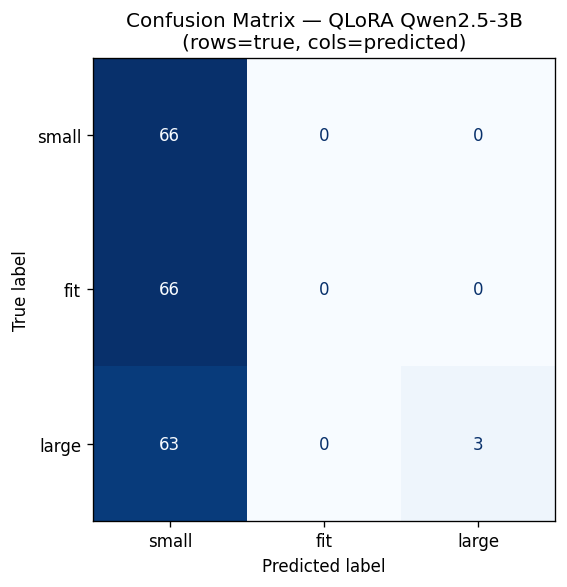

              precision    recall  f1-score   support

       small       0.00      0.00      0.00        66
         fit       1.00      0.05      0.09        66
       large       0.34      1.00      0.51        66

    accuracy                           0.35       198
   macro avg       0.45      0.35      0.20       198
weighted avg       0.45      0.35      0.20       198



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [10]:
y_true = pred_df['true_label']
y_pred = pred_df['pred_label']

cm = confusion_matrix(y_true, y_pred, labels=LABEL_NAMES)
disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — QLoRA Qwen2.5-3B\n(rows=true, cols=predicted)')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))

In [11]:
# Show 2 real examples for each error type
errors = pred_df[~pred_df['correct']].copy()
print(f'Total errors: {len(errors)} / {len(pred_df)} ({len(errors)/len(pred_df):.1%})')
print()

for true_cls in LABEL_NAMES:
    for pred_cls in LABEL_NAMES:
        if true_cls == pred_cls:
            continue
        subset = errors[(errors['true_label'] == true_cls) & (errors['pred_label'] == pred_cls)]
        if len(subset) == 0:
            continue
        print(f'── TRUE={true_cls} → PREDICTED={pred_cls} ({len(subset)} cases) ──')
        for _, r in subset.head(2).iterrows():
            review_snippet = r['review_text'][:120] if r['review_text'] else '(no review)'
            print(f'  Review:      "{review_snippet}"')
            print(f'  Explanation: "{str(r["explanation"])[:100]}"')
            print(f'  Confidence:  {r["confidence"]:.2f}')
            print()

# Error rate by whether review was provided
has_review = pred_df['review_len'] > 20
print(f'Error rate with review:    {(~pred_df.loc[has_review, "correct"]).mean():.1%}')
print(f'Error rate without review: {(~pred_df.loc[~has_review, "correct"]).mean():.1%}')

Total errors: 129 / 198 (65.2%)

── TRUE=fit → PREDICTED=small (66 cases) ──
  Review:      "I wore this dress to my boyfriend's Air Force pilot training graduation and wing pinning. I comfortably wore this dress "
  Explanation: "This item runs small — consider sizing up. Customer noted: "I wore this dress to my boyfriend's Air "
  Confidence:  0.85

  Review:      "Unfortunately didn't get to wear the dress as the birthday brunch I bought it for was cancelled but I wore it around the"
  Explanation: "This item runs small — consider sizing up. Customer noted: "Unfortunately didn't get to wear the dre"
  Confidence:  0.90

── TRUE=large → PREDICTED=small (63 cases) ──
  Review:      "Since almost all of the reviews mention that this is oversized (it's supposed to be), I sized down to a Small (it fits g"
  Explanation: "This item runs small — consider sizing up. Customer noted: "Since almost all of the reviews mention "
  Confidence:  0.90

  Review:      "Nothing NOT to love about this

## Section 4 — Confidence Calibration

A **well-calibrated** model: when it says confidence = 0.9, it's right 90% of the time.
LLMs are often *overconfident* — this plot shows how bad the miscalibration is.

**Expected finding:** The model will likely say 0.9+ confidence for most predictions regardless of correctness.
This is a known limitation of fine-tuned LLMs vs probabilistic classifiers.

confidence_bucket  actual_accuracy  count
          0.8-0.9         0.395973    149
          0.9-1.0         0.204082     49


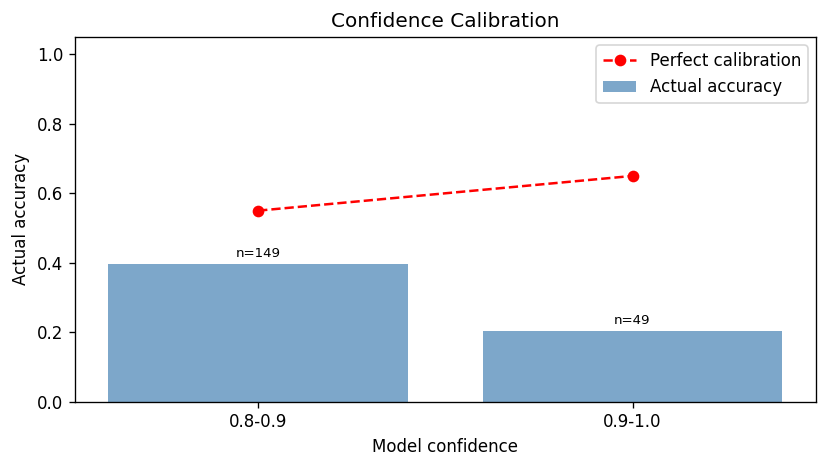


Avg confidence when CORRECT: 0.848
Avg confidence when WRONG:   0.862

Overconfident failures (conf≥0.85, wrong): 122


In [12]:
bins    = [0.5, 0.6, 0.7, 0.8, 0.9, 1.01]
labels  = ['0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
pred_df['conf_bucket'] = pd.cut(pred_df['confidence'], bins=bins, labels=labels, right=False)

cal = pred_df.groupby('conf_bucket', observed=True)['correct'].agg(['mean', 'count']).reset_index()
cal.columns = ['confidence_bucket', 'actual_accuracy', 'count']
print(cal.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(cal))
ax.bar(x, cal['actual_accuracy'], color='steelblue', alpha=0.7, label='Actual accuracy')
# Ideal calibration line: midpoint of each bucket
ideal = [0.55, 0.65, 0.75, 0.85, 0.95]
ax.plot(x, ideal[:len(cal)], 'r--o', label='Perfect calibration')
ax.set_xticks(x)
ax.set_xticklabels(cal['confidence_bucket'])
ax.set_xlabel('Model confidence')
ax.set_ylabel('Actual accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Confidence Calibration')
ax.legend()
for i, (acc, cnt) in enumerate(zip(cal['actual_accuracy'], cal['count'])):
    ax.text(i, acc + 0.02, f'n={cnt}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('results/calibration.png', dpi=150)
plt.show()

print(f"\nAvg confidence when CORRECT: {pred_df.loc[pred_df['correct'], 'confidence'].mean():.3f}")
print(f"Avg confidence when WRONG:   {pred_df.loc[~pred_df['correct'], 'confidence'].mean():.3f}")

overconfident = pred_df[(pred_df['confidence'] >= 0.85) & (~pred_df['correct'])]
print(f"\nOverconfident failures (conf≥0.85, wrong): {len(overconfident)}")

## Section 5 — Segment Analysis

Aggregate F1 hides subgroup failures. We break down performance by:
- **Item category** — does it work better for Dresses vs Tops?
- **Body type** — any systematic bias?
- **Review length** — does having more text help?

In [13]:
def segment_f1(df, col, min_samples=5):
    """Compute macro F1 per segment value. Only show segments with >= min_samples."""
    rows = []
    for val, grp in df.groupby(col):
        if len(grp) < min_samples:
            continue
        f1 = f1_score(grp['true_label'], grp['pred_label'], average='macro',
                      labels=LABEL_NAMES, zero_division=0)
        acc = grp['correct'].mean()
        rows.append({'segment': val, 'count': len(grp), 'macro_f1': f1, 'accuracy': acc})
    return pd.DataFrame(rows).sort_values('macro_f1', ascending=False)

# ── By category ──────────────────────────────────────────────────────────────
print('=== By Item Category ===')
cat_f1 = segment_f1(pred_df, 'category')
print(cat_f1.to_string(index=False))

print('\n=== By Body Type ===')
body_f1 = segment_f1(pred_df, 'body_type')
print(body_f1.to_string(index=False))

# ── By review length bucket ───────────────────────────────────────────────────
pred_df['review_bucket'] = pd.cut(
    pred_df['review_len'],
    bins=[-1, 0, 100, 300, 10000],
    labels=['no review', 'short (<100)', 'medium (100-300)', 'long (300+)']
)
print('\n=== By Review Length ===')
rev_f1 = segment_f1(pred_df, 'review_bucket', min_samples=2)
print(rev_f1.to_string(index=False))

=== By Item Category ===
segment  count  macro_f1  accuracy
  pants      5  0.300000  0.400000
  skirt      5  0.250000  0.600000
  dress     87  0.210515  0.390805
 sheath     20  0.190476  0.400000
  shift      5  0.190476  0.400000
    top     10  0.153846  0.300000
   gown     36  0.121212  0.222222
 jacket      5  0.111111  0.200000
   maxi      6  0.095238  0.166667

=== By Body Type ===
          segment  count  macro_f1  accuracy
straight & narrow     20  0.234074  0.350000
           petite     20  0.220606  0.350000
          unknown     15  0.212121  0.466667
         athletic     48  0.196078  0.416667
            apple      5  0.190476  0.400000
        full bust     11  0.177778  0.363636
        hourglass     58  0.172222  0.275862
             pear     21  0.148148  0.285714

=== By Review Length ===
         segment  count  macro_f1  accuracy
     long (300+)     72  0.230392  0.444444
medium (100-300)     94  0.172119  0.276596
    short (<100)     32  0.170543  0.343

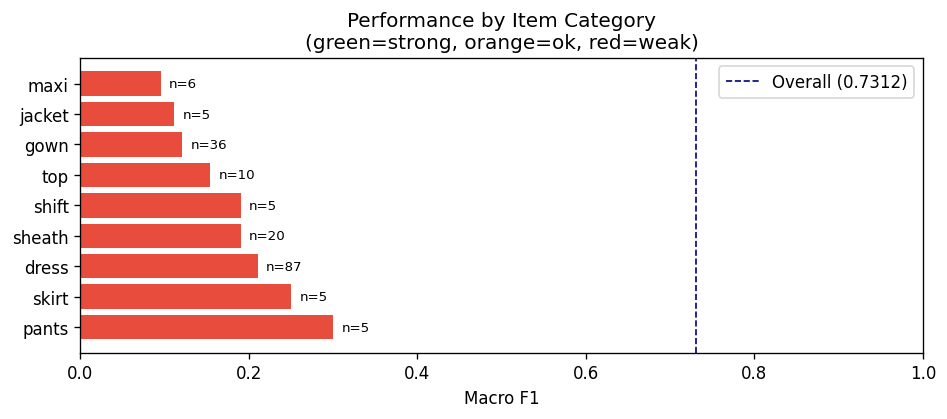

In [14]:
# Visual: accuracy by category (horizontal bar chart)
if len(cat_f1) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3, len(cat_f1) * 0.4)))
    colors = ['#2ecc71' if f1 >= 0.7 else '#e74c3c' if f1 < 0.5 else '#f39c12'
              for f1 in cat_f1['macro_f1']]
    ax.barh(cat_f1['segment'], cat_f1['macro_f1'], color=colors)
    ax.axvline(0.7312, color='navy', linestyle='--', linewidth=1, label='Overall (0.7312)')
    ax.set_xlabel('Macro F1')
    ax.set_title('Performance by Item Category\n(green=strong, orange=ok, red=weak)')
    ax.set_xlim(0, 1)
    ax.legend()
    for i, (f1, cnt) in enumerate(zip(cat_f1['macro_f1'], cat_f1['count'])):
        ax.text(f1 + 0.01, i, f'n={cnt}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('results/segment_analysis.png', dpi=150)
    plt.show()

## Section 6 — LLM-as-a-Judge (OpenAI GPT-4o-mini)

We sample 100 predictions (stratified: ~33 per class, mix of correct + incorrect) and ask GPT-4o-mini:
1. **ACCURACY**: Is the predicted fit correct? (`yes / no / ambiguous`)
2. **EXPLANATION_QUALITY**: Is the explanation useful and grounded in the review? (`excellent / good / poor`)

**Why this matters:** F1 assumes ground truth labels are perfect. But some reviews are ambiguous —
the LLM judge can flag cases where the model's answer is actually *better* than the label.

**Cost:** ~100 × 400 tokens × $0.00015/1k = **< $0.10 total**

In [ ]:
OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', '')   # set via: export OPENAI_API_KEY=sk-...

if not OPENAI_API_KEY:
    print('Set OPENAI_API_KEY environment variable to run this section.')
    print('In terminal: export OPENAI_API_KEY=sk-...')
    print('Then restart the kernel and re-run.')
else:
    from openai import OpenAI
    from tqdm import tqdm as tqdm_auto
    import time

    client = OpenAI(api_key=OPENAI_API_KEY)

    JUDGE_PROMPT = """You are evaluating a clothing fit prediction AI.

Customer profile: height {height_in}in, weight {weight_lbs}lbs, body_type={body_type}, age={age}, bust={bust}
Item ordered: category={category}, size={size}
Review text: "{review}"

The AI predicted: {pred_label} (confidence: {confidence:.2f})
AI explanation: "{explanation}"
Ground truth label: {true_label}

Rate on TWO dimensions:
1. ACCURACY: Is the predicted fit label correct given ALL available evidence? Answer 'yes', 'no', or 'ambiguous' (use ambiguous if the review is unclear or the label is debatable).
2. EXPLANATION_QUALITY: Is the explanation helpful, specific, and grounded in the review text? Answer 'excellent', 'good', or 'poor'.

Respond ONLY with JSON: {{"accuracy": "yes|no|ambiguous", "explanation_quality": "excellent|good|poor", "judge_comment": "one sentence"}}"""

    # Stratified sample for judging: ~33 per class, mix correct+incorrect
    judge_sample = pd.concat([
        pred_df[pred_df['true_label'] == cls].sample(n=min(34, (pred_df['true_label'] == cls).sum()), random_state=7)
        for cls in LABEL_NAMES
    ]).sample(frac=1, random_state=7).head(100).reset_index(drop=True)

    judge_results = []
    for _, row in tqdm_auto(judge_sample.iterrows(), total=len(judge_sample), desc='Judging'):
        prompt = JUDGE_PROMPT.format(
            height_in=row['height_in'], weight_lbs=row['weight_lbs'],
            body_type=row['body_type'], age=row['age'], bust=row['bust'],
            category=row['category'], size=row['size'],
            review=str(row['review_text'])[:200],
            pred_label=row['pred_label'], confidence=float(row['confidence']),
            explanation=str(row['explanation'])[:150],
            true_label=row['true_label'],
        )
        try:
            resp = client.chat.completions.create(
                model='gpt-4o-mini',
                messages=[{'role': 'user', 'content': prompt}],
                temperature=0,
                max_tokens=120,
            )
            verdict = json.loads(resp.choices[0].message.content.strip())
        except Exception as e:
            verdict = {'accuracy': 'ambiguous', 'explanation_quality': 'poor', 'judge_comment': str(e)}
        judge_results.append({
            **row.to_dict(),
            'judge_accuracy': verdict.get('accuracy', 'ambiguous'),
            'judge_expl_quality': verdict.get('explanation_quality', 'poor'),
            'judge_comment': verdict.get('judge_comment', ''),
        })
        time.sleep(0.05)  # gentle rate limiting

    judge_df = pd.DataFrame(judge_results)
    judge_df.to_csv('results/judge_results.csv', index=False)

    # ── Aggregate judge scores ─────────────────────────────────────────────────
    print('=== LLM Judge Results (n=100) ===')
    print(f"Judge says ACCURATE:   {(judge_df['judge_accuracy'] == 'yes').mean():.1%}")
    print(f"Judge says AMBIGUOUS:  {(judge_df['judge_accuracy'] == 'ambiguous').mean():.1%}")
    print(f"Judge says WRONG:      {(judge_df['judge_accuracy'] == 'no').mean():.1%}")
    print()
    print(f"Explanation EXCELLENT: {(judge_df['judge_expl_quality'] == 'excellent').mean():.1%}")
    print(f"Explanation GOOD:      {(judge_df['judge_expl_quality'] == 'good').mean():.1%}")
    print(f"Explanation POOR:      {(judge_df['judge_expl_quality'] == 'poor').mean():.1%}")

    # Cases where judge agrees with model but disagrees with ground truth (ambiguous labels)
    interesting = judge_df[(judge_df['judge_accuracy'] == 'ambiguous') | 
                           ((judge_df['judge_accuracy'] == 'yes') & (~judge_df['correct']))]
    print(f'\nInteresting cases (judge disagrees with ground truth): {len(interesting)}')
    for _, r in interesting.head(3).iterrows():
        print(f'  True={r["true_label"]} | Pred={r["pred_label"]} | Judge={r["judge_accuracy"]}')
        print(f'  Review: "{str(r["review_text"])[:100]}"')
        print(f'  Comment: {r["judge_comment"]}')
        print()

Judging:  91%|█████████ | 91/100 [02:25<00:13,  1.45s/it]

## Section 7 — Robustness / Edge Case Tests

10 hand-crafted inputs to stress-test the model before deployment.
This is the ML equivalent of unit testing.

**Run on RunPod** if model isn't loaded locally (set `model` and `tokenizer` from Section 2 first).

In [ ]:
def predict_fit(review, height_in, weight_lbs, body_type, age, bust, category, size):
    bmi = compute_bmi(height_in, weight_lbs)
    bmi_str = f', BMI {bmi}' if bmi else ''
    review_part = f'\nReview: "{review[:300]}"' if str(review).strip() else '\nReview: (none provided)'
    inp = (
        f'Customer: height {height_in}in, weight {weight_lbs}lbs{bmi_str}, '
        f'body_type {body_type}, age {age}, bust {bust}\n'
        f'Item: category={category}, ordered size={size}'
        f'{review_part}\n\n'
        'Respond ONLY with JSON:\n'
        '{"predicted_fit": "small|fit|large", "confidence": 0.0-1.0, '
        '"recommended_action": "size_down|stay|size_up", "explanation": "..."}'
    )
    prompt = (
        f'<|im_start|>system\n{INSTRUCTION}<|im_end|>\n'
        f'<|im_start|>user\n{inp}<|im_end|>\n'
        f'<|im_start|>assistant\n'
    )
    inputs = tokenizer([prompt], return_tensors='pt').to('cuda')
    outputs = model.generate(**inputs, max_new_tokens=200, temperature=0.1, do_sample=False)
    response = tokenizer.decode(outputs[0][len(inputs.input_ids[0]):], skip_special_tokens=True)
    return extract_json(response)

edge_cases = [
    ('Empty review',                        dict(review='', height_in=65, weight_lbs=140, body_type='hourglass', age=28, bust='36', category='Dresses', size='M')),
    ('Review says fits, XS on large frame', dict(review='I love this dress, fits perfectly!', height_in=68, weight_lbs=185, body_type='straight', age=35, bust='40', category='Dresses', size='XS')),
    ('Clear small signal',                  dict(review='Runs really small, had to return and size up two sizes!', height_in=65, weight_lbs=130, body_type='petite', age=24, bust='34', category='Tops', size='M')),
    ('Clear large signal',                  dict(review='Way too big and boxy on me, swimming in it', height_in=63, weight_lbs=115, body_type='straight', age=22, bust='32', category='Dresses', size='L')),
    ('Vague review',                        dict(review="It's okay I guess", height_in=66, weight_lbs=145, body_type='athletic', age=30, bust='36', category='Tops', size='S')),
    ('Emoji-heavy review',                  dict(review='Sooo cute!! 😍 but wayyy too small 😭 ordered a size up', height_in=64, weight_lbs=135, body_type='hourglass', age=26, bust='36', category='Dresses', size='M')),
    ('Contradictory signals',               dict(review='Love the fabric and style, fits great!', height_in=70, weight_lbs=200, body_type='plus size', age=40, bust='44', category='Dresses', size='XS')),
    ('Extreme measurements',                dict(review='Perfect fit for my body type', height_in=74, weight_lbs=260, body_type='athletic', age=45, bust='48', category='Gowns', size='S')),
    ('Very short review',                   dict(review='Small.', height_in=65, weight_lbs=130, body_type='petite', age=25, bust='34', category='Tops', size='L')),
    ('No measurements (zeros)',             dict(review='Runs small, needed to size up', height_in=0, weight_lbs=0, body_type='unknown', age=0, bust='unknown', category='Dresses', size='M')),
]

header = f"{'Test':<42} {'Predicted':>10} {'Conf':>6}  Explanation"
print(header)
print('-' * 100)
for name, kwargs in edge_cases:
    try:
        result = predict_fit(**kwargs)
        if result:
            expl = result.get('explanation', '')[:55]
            pred = result['predicted_fit']
            conf = result['confidence']
            print(f'{name:<42} {pred:>10} {conf:>6.2f}  {expl}')
        else:
            print(f'{name:<42} {"JSON FAIL":>10}')
    except Exception as e:
        print(f'{name:<42} {"ERROR":>10}  {str(e)[:55]}')

## Section 8 — Final Scorecard

The complete evaluation report.

In [ ]:
full_results = json.load(open('trained-info/results/results/llm_eval.json'))
gate         = json.load(open('trained-info/results/results/baseline.json'))

judge_summary = {}
if os.path.exists('results/judge_results.csv'):
    jdf = pd.read_csv('results/judge_results.csv')
    judge_summary = {
        'judge_accurate_pct':  float((jdf['judge_accuracy'] == 'yes').mean()),
        'judge_excellent_pct': float((jdf['judge_expl_quality'] == 'excellent').mean()),
        'judge_good_pct':      float((jdf['judge_expl_quality'] == 'good').mean()),
    }

zs_macro = None
if os.path.exists('results/zeroshot_sample.csv'):
    _zdf = pd.read_csv('results/zeroshot_sample.csv')
    zs_macro = f1_score(_zdf['true_label'], _zdf['pred_label'], average='macro', labels=LABEL_NAMES)

print('=' * 68)
print('             CLOTHFIT MODEL EVALUATION REPORT')
print('=' * 68)
print(f'{"Metric":<30} {"Random":>8} {"CatBoost":>10} {"Zero-shot":>10} {"Fine-tuned":>10}')
print('-' * 68)

rows_report = [
    ('Macro F1 (full test)',  0.333, gate['tfidf_baseline_macro_f1'], zs_macro,  full_results['llm_macro_f1']),
    ('Small F1',              None,  gate['baseline_small_f1'],        None,      full_results['llm_small_f1']),
    ('Large F1',              None,  gate['baseline_large_f1'],        None,      full_results['llm_large_f1']),
    ('JSON Validity',         None,  None,                             None,      full_results['json_validity']),
]
for name, rand, base, zs, llm in rows_report:
    rand_s = f'{rand:.3f}' if rand is not None else 'N/A'
    base_s = f'{base:.4f}' if base is not None else 'N/A'
    zs_s   = f'{zs:.4f}'   if zs   is not None else 'N/A'
    llm_s  = f'{llm:.4f}'  if isinstance(llm, float) and llm <= 1 else f'{llm:.1%}'
    flag   = ' ✓' if (base is None or llm > base) else ' ✗'
    print(f'{name:<30} {rand_s:>8} {base_s:>10} {zs_s:>10} {llm_s:>10}{flag}')

if zs_macro:
    gain = full_results['llm_macro_f1'] - zs_macro
    print(f'\nFine-tuning gain over zero-shot: +{gain*100:.1f} F1 points')

if judge_summary:
    print('-' * 68)
    good = judge_summary['judge_excellent_pct'] + judge_summary['judge_good_pct']
    print(f'{"LLM Judge: Accuracy":<30} {"N/A":>8} {"N/A":>10} {"N/A":>10} {judge_summary["judge_accurate_pct"]:>10.1%}')
    print(f'{"LLM Judge: Expl. Quality":<30} {"N/A":>8} {"N/A":>10} {"N/A":>10} {good:>10.1%}')

print('=' * 68)
print(f'Estimated human agreement (upper ceiling): ~85–90%')
print(f'Original paper best result (Misra 2018):   ~0.62–0.65')
print('=' * 68)
verdict = 'DEPLOY ✓' if full_results['passes_gate'] else 'DO NOT DEPLOY ✗'
print(f'VERDICT: {verdict}')
print('=' * 68)

report = {
    **full_results,
    'sample_macro_f1':       float(macro_f1),
    'sample_accuracy':       float(overall_acc),
    'json_validity_sample':  float(json_validity),
    'zeroshot_macro_f1':     float(zs_macro) if zs_macro else None,
    'random_baseline_f1':    0.333,
    'original_paper_f1_est': 0.635,
    'human_ceiling_est':     0.875,
    **judge_summary,
}
with open('results/eval_report.json', 'w') as f:
    json.dump(report, f, indent=2)
print(f'\nFull report saved → results/eval_report.json')